<a href="https://colab.research.google.com/github/Jaya-323/Python_AI_ML_practice/blob/main/Practice6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification of datset

In [ ]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
import seaborn as sns
print("Library imported")


Library imported


In [ ]:
data={
    "hours":[3,8,4,5,6,1,7],
    "attendance":["Yes","No" ,"Yes","No","Yes","Yes","No"],
    "gender":["Male","Female","Female","Male","Male","Female","Female"],
    "result":[1,0,1,1,0,1,1]
}
df=pd.DataFrame(data)
print(df)

   hours attendance  gender  result
0      3        Yes    Male       1
1      8         No  Female       0
2      4        Yes  Female       1
3      5         No    Male       1
4      6        Yes    Male       0
5      1        Yes  Female       1
6      7         No  Female       1


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hours       7 non-null      int64 
 1   attendance  7 non-null      object
 2   gender      7 non-null      object
 3   result      7 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 356.0+ bytes
None


Label encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df["attendance"]=encoder.fit_transform(df["attendance"])
df["gender"]=encoder.fit_transform(df["gender"])
print(df)

   hours  attendance  gender  result
0      3           1       1       1
1      8           0       0       0
2      4           1       0       1
3      5           0       1       1
4      6           1       1       0
5      1           1       0       1
6      7           0       0       1


One hot encoding

In [ ]:
encoded_df=pd.get_dummies(df,columns=["attendance","gender"])
#encoded_df1=pd.get_dummies(df,columns=["gender"])
print(encoded_df)
#print(encoded_df1)

   hours  result  attendance_0  attendance_1  gender_0  gender_1
0      3       1         False          True     False      True
1      8       0          True         False      True     False
2      4       1         False          True      True     False
3      5       1          True         False     False      True
4      6       0         False          True     False      True
5      1       1         False          True      True     False
6      7       1          True         False      True     False


In [ ]:
X=df[["hours","attendance","gender"]]
y=df["result"]
print(X.shape)
print(y.shape)

(7, 3)
(7,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(X)
print(X)

[[-0.83223972  0.8660254   1.15470054]
 [ 1.40840568 -1.15470054 -0.8660254 ]
 [-0.38411064  0.8660254  -0.8660254 ]
 [ 0.06401844 -1.15470054  1.15470054]
 [ 0.51214752  0.8660254   1.15470054]
 [-1.72849788  0.8660254  -0.8660254 ]
 [ 0.9602766  -1.15470054 -0.8660254 ]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=40)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[ 0.51214752  0.8660254   1.15470054]
 [-0.83223972  0.8660254   1.15470054]
 [ 0.06401844 -1.15470054  1.15470054]
 [ 0.9602766  -1.15470054 -0.8660254 ]]
[[-1.72849788  0.8660254  -0.8660254 ]
 [ 1.40840568 -1.15470054 -0.8660254 ]
 [-0.38411064  0.8660254  -0.8660254 ]]
4    0
0    1
3    1
6    1
Name: result, dtype: int64
5    1
1    0
2    1
Name: result, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
print("Training completed")

Training completed


In [ ]:
prediction=model.predict(X_test)
print(prediction)

[1 1 1]


In [ ]:
new=[[0,0,1]]
nd=scaler.transform(new)
np=model.predict(nd)
print("New prediction:",np)

New prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Comparision

In [ ]:
comparision=pd.DataFrame(
    {
      "Actual":y_test,
        "Predicted":prediction
}
    )
print(comparision)

   Actual  Predicted
5       1          1
1       0          1
2       1          1


Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,prediction))

0.6666666666666666


Confusion metrics

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,prediction))

[[0 1]
 [0 2]]


Confusion matrix heatmap

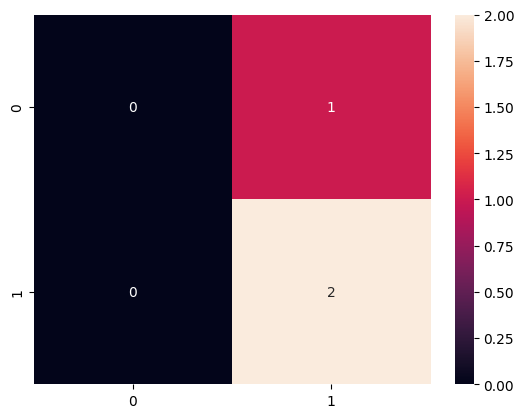

In [ ]:
sns.heatmap(confusion_matrix(y_test,prediction),annot=True)

plt.show()